# Qualitative Direct v2: Model- and Sample-Level Analysis

This notebook analyzes `Qualitative_Direct_v2.csv` in the requested order. OmniScore columns are expected to contain the current **reference-based** scores.

The notebook contains 14 numbered analysis cells: Cells 1–7 report model-level statistics, and Cells 8–14 report sample-level and integrated statistics.


In [1]:
# Shared setup
from pathlib import Path
from itertools import combinations
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")


def find_repo_root(start: Path) -> Path:
    relative_path = Path("annotations/summary_hallucination/Qualitative_Direct_v2.csv")
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / relative_path).exists():
            return candidate
    raise FileNotFoundError(f"Could not locate {relative_path} from {start.resolve()}")


def summary_table(data: pd.DataFrame, metrics: list[str], group: str = "model_name") -> pd.DataFrame:
    long = data.melt(id_vars=[group], value_vars=metrics, var_name="metric", value_name="value")
    result = long.groupby([group, "metric"], observed=True)["value"].agg(
        count="count", mean="mean", std="std", median="median", minimum="min", maximum="max"
    )
    result["sem"] = result["std"] / np.sqrt(result["count"])
    result["ci95_low"] = result["mean"] - 1.96 * result["sem"]
    result["ci95_high"] = result["mean"] + 1.96 * result["sem"]
    return result.reset_index()


def metric_boxplots(data: pd.DataFrame, metrics: list[str], title: str, figsize: tuple[int, int]) -> None:
    long = data.melt(id_vars=["model_name"], value_vars=metrics, var_name="metric", value_name="value")
    fig, axes = plt.subplots(1, len(metrics), figsize=figsize, squeeze=False)
    for axis, metric in zip(axes.flat, metrics):
        subset = long[long["metric"].eq(metric)]
        sns.boxplot(data=subset, x="model_name", y="value", order=MODEL_ORDER, ax=axis, color="#72B7B2", showfliers=False)
        sns.stripplot(data=subset, x="model_name", y="value", order=MODEL_ORDER, ax=axis, color="black", alpha=0.15, size=2)
        axis.set_title(metric)
        axis.set_xlabel("")
        axis.tick_params(axis="x", rotation=35)
    fig.suptitle(title, y=1.03)
    plt.tight_layout()
    plt.show()


ROOT = find_repo_root(Path.cwd())
DATA_PATH = ROOT / "annotations/summary_hallucination/Qualitative_Direct_v2.csv"
df = pd.read_csv(DATA_PATH)

MODEL_ORDER = ["aya-expanse:8b", "gemma4:e4b", "qwen3.5:9b", "mBART-large"]
SLM_MODELS = MODEL_ORDER[:-1]
ROUGE_COLS = ["rouge1", "rouge2", "rougeL"]
BERTSCORE_COLS = ["bs_f1_raw"]
OMNISCORE_COLS = ["informativeness", "clarity", "plausibility", "faithfulness"]
METRIC_COLS = ROUGE_COLS + BERTSCORE_COLS + OMNISCORE_COLS + ["Length Ratio"]
HALLUCINATION_LABELS = ["H-ENT", "H-EVT", "H-ROLE", "H-CIRC", "H-MOD", "H-DISC"]
TAXONOMY_LABELS = HALLUCINATION_LABELS + ["OMIT", "LANG", "NO-ERROR"]

required = {"model_name", "sample_index", "error_label", "Review_Notes", "dialogue", "reference", "prediction", *METRIC_COLS}
missing = required - set(df.columns)
assert not missing, f"Missing columns: {sorted(missing)}"
assert len(df) == 400
assert not df.duplicated(["model_name", "sample_index"]).any()
assert set(df["model_name"]) == set(MODEL_ORDER)
assert df.groupby("model_name").size().eq(100).all()
assert df.groupby("sample_index")["model_name"].nunique().eq(4).all()
assert df.groupby("sample_index")["dialogue"].nunique().eq(1).all()

for column in METRIC_COLS:
    df[column] = pd.to_numeric(df[column], errors="raise")

df["model_name"] = pd.Categorical(df["model_name"], categories=MODEL_ORDER, ordered=True)
df["label_list"] = df["error_label"].str.split("|")
assert df["label_list"].explode().isin(TAXONOMY_LABELS).all(), "Unknown taxonomy label found"
df["is_no_error"] = df["error_label"].eq("NO-ERROR")
df["has_error"] = ~df["is_no_error"]
df["is_hallucination"] = df["label_list"].apply(lambda labels: any(label.startswith("H-") for label in labels))
df["is_omit"] = df["label_list"].apply(lambda labels: "OMIT" in labels)
df["is_lang"] = df["label_list"].apply(lambda labels: "LANG" in labels)
df["is_multi_label"] = df["label_list"].str.len().gt(1)
df["rouge_mean"] = df[ROUGE_COLS].mean(axis=1)
df["system_family"] = np.where(df["model_name"].eq("mBART-large"), "mBART", "SLMs")

LENGTH_BIN_ORDER = ["<0.75", "0.75-1.25", "1.25-2.0", "2.0-4.0", ">4.0"]
df["length_ratio_bin"] = pd.cut(
    df["Length Ratio"],
    bins=[-np.inf, 0.75, 1.25, 2.0, 4.0, np.inf],
    labels=LENGTH_BIN_ORDER,
    right=False,
)

label_long = (
    df[["model_name", "sample_index", "system_family", "Length Ratio", "length_ratio_bin", "label_list"]]
    .explode("label_list")
    .rename(columns={"label_list": "label"})
)

display(pd.DataFrame({"value": [len(df), df["sample_index"].nunique(), df["model_name"].nunique(), str(DATA_PATH)]},
                     index=["rows", "samples", "models", "source"]))


,value
rows,400
samples,100
models,4
source,/Users/yunu919/Desktop/grounded-semantic-pipeline/annotations/summary_hallucination/Qualitative_Direct_v2.csv


## Cell 1. Overall Error-Label Distribution

,count,row_rate,share_of_label_occurrences
label,,,
H-ENT,39,0.0975,0.0759
H-EVT,54,0.1350,0.1051
H-ROLE,61,0.1525,0.1187
H-CIRC,39,0.0975,0.0759
H-MOD,26,0.0650,0.0506
H-DISC,22,0.0550,0.0428
OMIT,66,0.1650,0.1284
LANG,28,0.0700,0.0545
NO-ERROR,179,0.4475,0.3482


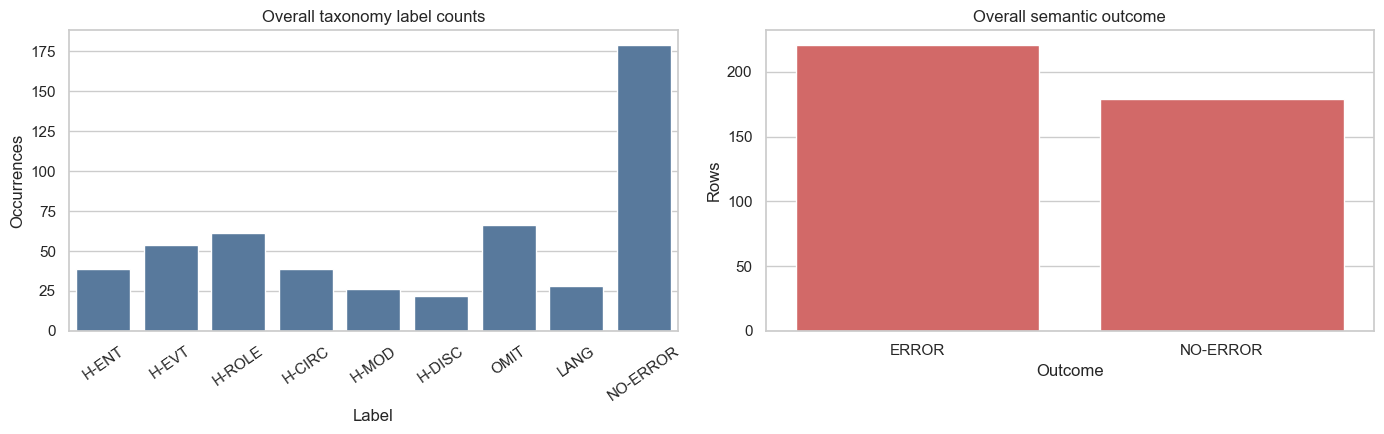

In [2]:
# Cell 1: Overall error-label distribution
display(Markdown("## Cell 1. Overall Error-Label Distribution"))

overall_label_distribution = label_long["label"].value_counts().reindex(TAXONOMY_LABELS, fill_value=0).rename("count").to_frame()
overall_label_distribution["row_rate"] = overall_label_distribution["count"] / len(df)
overall_label_distribution["share_of_label_occurrences"] = overall_label_distribution["count"] / overall_label_distribution["count"].sum()
display(overall_label_distribution.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=overall_label_distribution.index, y=overall_label_distribution["count"], ax=axes[0], color="#4C78A8")
axes[0].set(title="Overall taxonomy label counts", xlabel="Label", ylabel="Occurrences")
axes[0].tick_params(axis="x", rotation=35)

binary_distribution = df["is_no_error"].map({True: "NO-ERROR", False: "ERROR"}).value_counts()
sns.barplot(x=binary_distribution.index, y=binary_distribution.values, ax=axes[1], color="#E45756")
axes[1].set(title="Overall semantic outcome", xlabel="Outcome", ylabel="Rows")
plt.tight_layout()
plt.show()


## Cell 2. Error-Label Distribution by Model

**Counts**

label,H-ENT,H-EVT,H-ROLE,H-CIRC,H-MOD,H-DISC,OMIT,LANG,NO-ERROR
model_name,,,,,,,,,
aya-expanse:8b,6,5,21,10,3,3,7,17,38
gemma4:e4b,10,6,5,3,5,2,8,0,63
qwen3.5:9b,7,11,14,10,3,7,3,0,58
mBART-large,16,32,21,16,15,10,48,11,20


**Rates per 100 model outputs**

label,H-ENT,H-EVT,H-ROLE,H-CIRC,H-MOD,H-DISC,OMIT,LANG,NO-ERROR
model_name,,,,,,,,,
aya-expanse:8b,0.06,0.05,0.21,0.10,0.03,0.03,0.07,0.17,0.38
gemma4:e4b,0.10,0.06,0.05,0.03,0.05,0.02,0.08,0.00,0.63
qwen3.5:9b,0.07,0.11,0.14,0.10,0.03,0.07,0.03,0.00,0.58
mBART-large,0.16,0.32,0.21,0.16,0.15,0.10,0.48,0.11,0.20


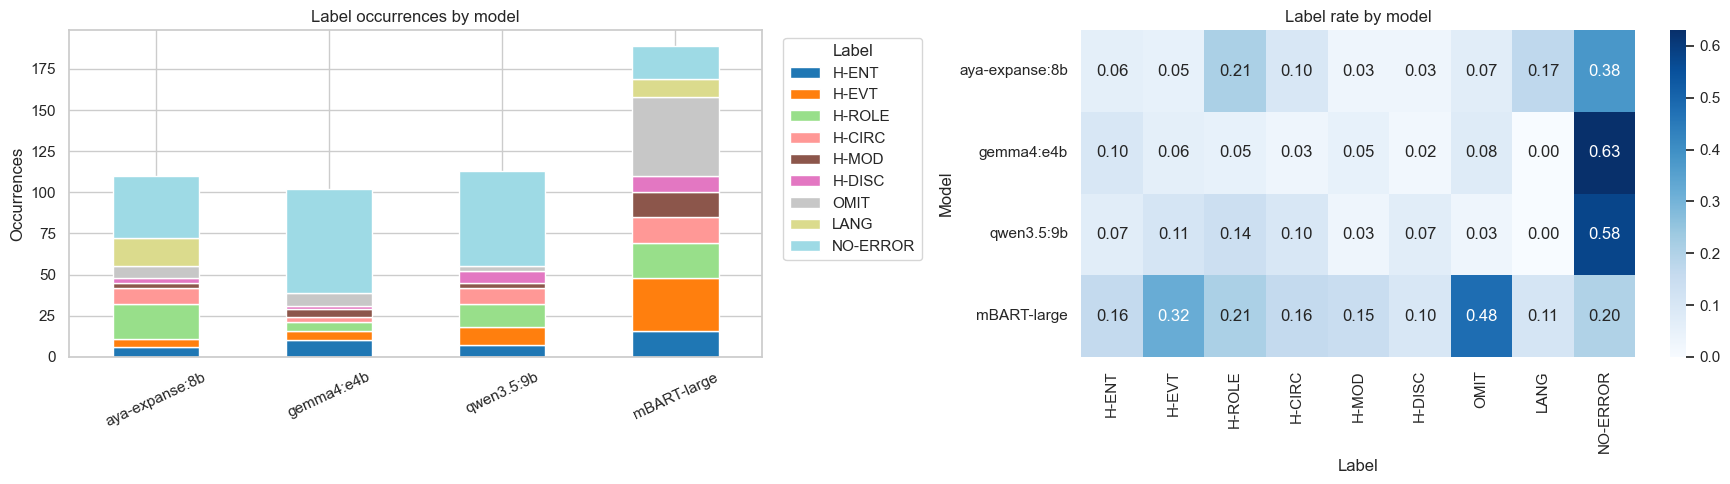

In [3]:
# Cell 2: Error-label distribution by model
display(Markdown("## Cell 2. Error-Label Distribution by Model"))

model_label_counts = (
    label_long.groupby(["model_name", "label"], observed=True).size()
    .unstack(fill_value=0).reindex(index=MODEL_ORDER, columns=TAXONOMY_LABELS, fill_value=0)
)
model_label_rates = model_label_counts.div(df.groupby("model_name", observed=True).size(), axis=0)
display(Markdown("**Counts**"))
display(model_label_counts)
display(Markdown("**Rates per 100 model outputs**"))
display(model_label_rates.round(3))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
model_label_counts.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20")
axes[0].set(title="Label occurrences by model", xlabel="", ylabel="Occurrences")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.heatmap(model_label_rates, annot=True, fmt=".2f", cmap="Blues", ax=axes[1])
axes[1].set(title="Label rate by model", xlabel="Label", ylabel="Model")
plt.tight_layout()
plt.show()


## Cell 3. Aggregated Semantic Score Comparison

**Overall**

,count,rate
NO-ERROR,179,0.448
Hallucination (any H-*),172,0.430
OMIT,66,0.165
LANG,28,0.070


**By model: counts**

,NO-ERROR,Hallucination (any H-*),OMIT,LANG
model_name,,,,
aya-expanse:8b,38,43,7,17
gemma4:e4b,63,29,8,0
qwen3.5:9b,58,39,3,0
mBART-large,20,61,48,11


**By model: rates**

,NO-ERROR,Hallucination (any H-*),OMIT,LANG
model_name,,,,
aya-expanse:8b,0.38,0.43,0.07,0.17
gemma4:e4b,0.63,0.29,0.08,0.00
qwen3.5:9b,0.58,0.39,0.03,0.00
mBART-large,0.20,0.61,0.48,0.11


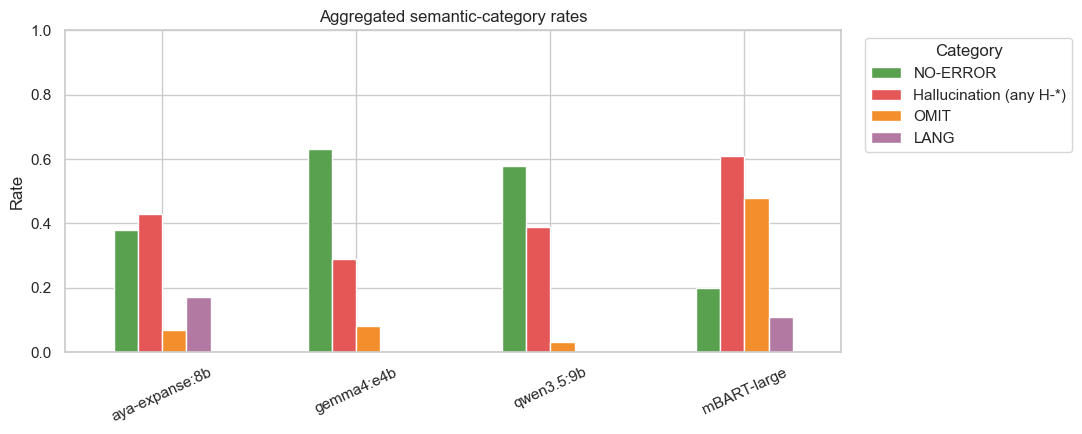

In [4]:
# Cell 3: Aggregated semantic score comparison
display(Markdown("## Cell 3. Aggregated Semantic Score Comparison"))

# These categories can overlap because a row may contain multiple labels.
semantic_columns = {
    "NO-ERROR": "is_no_error",
    "Hallucination (any H-*)": "is_hallucination",
    "OMIT": "is_omit",
    "LANG": "is_lang",
}
overall_semantic = pd.DataFrame({
    "count": {name: int(df[column].sum()) for name, column in semantic_columns.items()},
    "rate": {name: float(df[column].mean()) for name, column in semantic_columns.items()},
})
model_semantic_rates = pd.DataFrame({
    name: df.groupby("model_name", observed=True)[column].mean() for name, column in semantic_columns.items()
}).reindex(MODEL_ORDER)
model_semantic_counts = pd.DataFrame({
    name: df.groupby("model_name", observed=True)[column].sum() for name, column in semantic_columns.items()
}).reindex(MODEL_ORDER)
display(Markdown("**Overall**"))
display(overall_semantic.round(3))
display(Markdown("**By model: counts**"))
display(model_semantic_counts.astype(int))
display(Markdown("**By model: rates**"))
display(model_semantic_rates.round(3))

ax = model_semantic_rates.plot(kind="bar", figsize=(11, 4.5), color=["#59A14F", "#E45756", "#F28E2B", "#B279A2"])
ax.set(title="Aggregated semantic-category rates", xlabel="", ylabel="Rate", ylim=(0, 1))
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Cell 4. Length Ratio by Model

,model_name,metric,count,mean,std,median,minimum,maximum,sem,ci95_low,ci95_high
0,aya-expanse:8b,Length Ratio,100,3.5177,1.8938,2.8264,1.0606,10.5000,0.1894,3.1465,3.8889
1,gemma4:e4b,Length Ratio,100,2.3978,1.3516,2.0665,0.5161,8.6875,0.1352,2.1329,2.6628
2,qwen3.5:9b,Length Ratio,100,2.8943,1.5773,2.2999,1.0682,10.0000,0.1577,2.5851,3.2034
3,mBART-large,Length Ratio,100,1.0263,0.7530,0.8421,0.2055,4.7273,0.0753,0.8787,1.1739


**Length Ratio bin counts**

length_ratio_bin,<0.75,0.75-1.25,1.25-2.0,2.0-4.0,>4.0
model_name,,,,,
aya-expanse:8b,0,3,16,51,30
gemma4:e4b,3,13,29,43,12
qwen3.5:9b,0,3,30,45,22
mBART-large,37,41,15,5,2


**Length Ratio bin rates**

length_ratio_bin,<0.75,0.75-1.25,1.25-2.0,2.0-4.0,>4.0
model_name,,,,,
aya-expanse:8b,0.00,0.03,0.16,0.51,0.30
gemma4:e4b,0.03,0.13,0.29,0.43,0.12
qwen3.5:9b,0.00,0.03,0.30,0.45,0.22
mBART-large,0.37,0.41,0.15,0.05,0.02


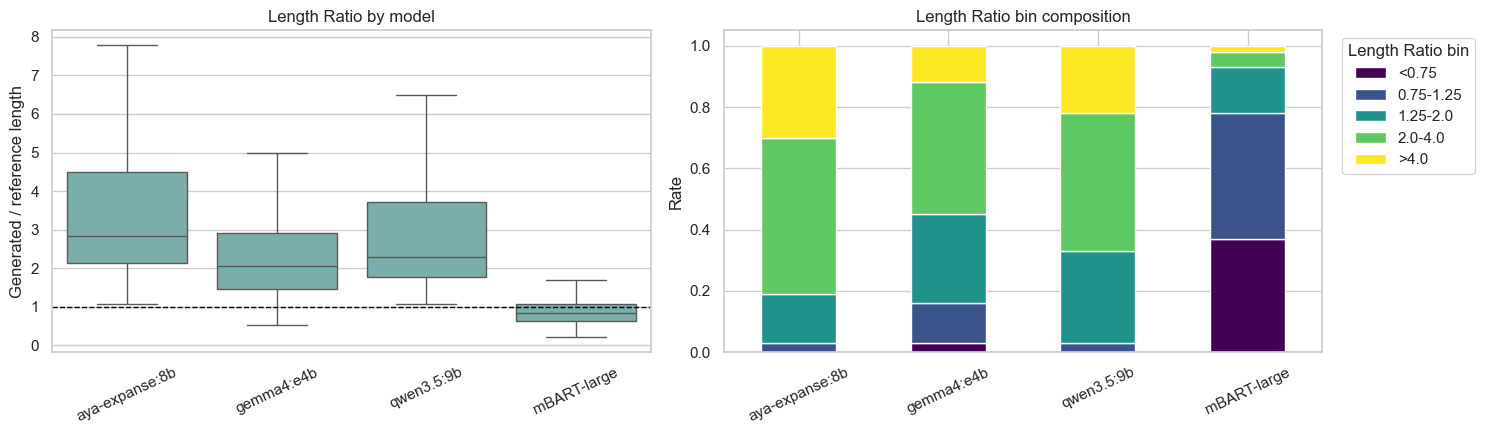

In [5]:
# Cell 4: Length Ratio by model
display(Markdown("## Cell 4. Length Ratio by Model"))
length_summary = summary_table(df, ["Length Ratio"])
length_bin_counts = pd.crosstab(df["model_name"], df["length_ratio_bin"]).reindex(index=MODEL_ORDER, columns=LENGTH_BIN_ORDER, fill_value=0)
length_bin_rates = length_bin_counts.div(length_bin_counts.sum(axis=1), axis=0)
display(length_summary.round(4))
display(Markdown("**Length Ratio bin counts**"))
display(length_bin_counts)
display(Markdown("**Length Ratio bin rates**"))
display(length_bin_rates.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.boxplot(data=df, x="model_name", y="Length Ratio", order=MODEL_ORDER, ax=axes[0], color="#72B7B2", showfliers=False)
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[0].set(title="Length Ratio by model", xlabel="", ylabel="Generated / reference length")
axes[0].tick_params(axis="x", rotation=25)
length_bin_rates.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set(title="Length Ratio bin composition", xlabel="", ylabel="Rate")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="Length Ratio bin", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Cell 5. ROUGE by Model

,model_name,metric,count,mean,std,median,minimum,maximum,sem,ci95_low,ci95_high
0,aya-expanse:8b,rouge1,100,26.5299,10.5824,24.280,5.26,51.28,1.0582,24.4558,28.6040
1,aya-expanse:8b,rouge2,100,7.8894,6.8097,5.970,0.00,28.28,0.6810,6.5547,9.2241
2,aya-expanse:8b,rougeL,100,20.8367,9.0155,19.230,5.26,51.28,0.9015,19.0697,22.6037
3,gemma4:e4b,rouge1,100,30.2712,11.3470,30.280,0.00,61.54,1.1347,28.0472,32.4952
4,gemma4:e4b,rouge2,100,8.3185,7.5136,7.365,0.00,34.15,0.7514,6.8458,9.7912
5,gemma4:e4b,rougeL,100,23.6818,10.2964,24.325,0.00,54.55,1.0296,21.6637,25.6999
6,qwen3.5:9b,rouge1,100,28.3485,11.1237,27.095,3.88,53.85,1.1124,26.1682,30.5288
7,qwen3.5:9b,rouge2,100,7.6234,8.2732,5.270,0.00,48.48,0.8273,6.0018,9.2450
8,qwen3.5:9b,rougeL,100,22.4177,10.0254,21.050,3.88,51.95,1.0025,20.4527,24.3827
9,mBART-large,rouge1,100,41.9480,19.0579,37.970,8.33,100.00,1.9058,38.2126,45.6834


**Mean ROUGE scores**

model_name,aya-expanse:8b,gemma4:e4b,qwen3.5:9b,mBART-large
metric,,,,
rouge1,26.530,30.271,28.348,41.948
rouge2,7.889,8.318,7.623,18.097
rougeL,20.837,23.682,22.418,34.855


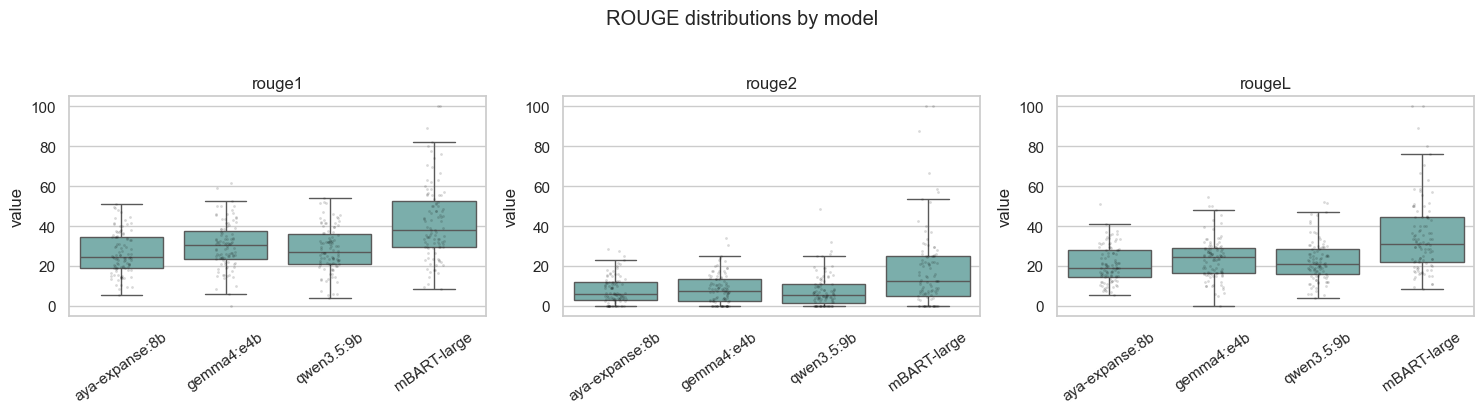

In [6]:
# Cell 5: ROUGE by model
display(Markdown("## Cell 5. ROUGE by Model"))

rouge_summary = summary_table(df, ROUGE_COLS)
rouge_means = rouge_summary.pivot(index="metric", columns="model_name", values="mean").reindex(columns=MODEL_ORDER)
display(rouge_summary.round(4))
display(Markdown("**Mean ROUGE scores**"))
display(rouge_means.round(3))
metric_boxplots(df, ROUGE_COLS, "ROUGE distributions by model", (15, 4))


## Cell 6. BERTScore by Model

,model_name,metric,count,mean,std,median,minimum,maximum,sem,ci95_low,ci95_high
0,aya-expanse:8b,bs_f1_raw,100,70.1144,4.6041,70.330,59.70,83.88,0.4604,69.2120,71.0168
1,gemma4:e4b,bs_f1_raw,100,70.8505,5.5809,71.065,57.16,84.79,0.5581,69.7566,71.9444
2,qwen3.5:9b,bs_f1_raw,100,70.4715,4.7198,70.320,56.95,83.35,0.4720,69.5464,71.3966
3,mBART-large,bs_f1_raw,100,77.6438,8.4031,76.165,60.94,100.00,0.8403,75.9968,79.2908


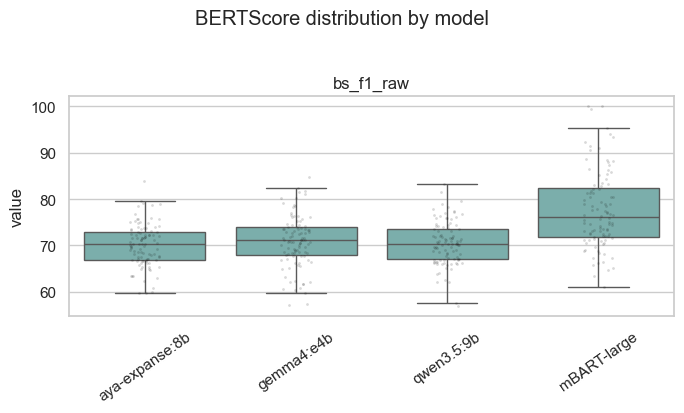

In [7]:
# Cell 6: BERTScore by model
display(Markdown("## Cell 6. BERTScore by Model"))

bertscore_summary = summary_table(df, BERTSCORE_COLS)
display(bertscore_summary.round(4))
metric_boxplots(df, BERTSCORE_COLS, "BERTScore distribution by model", (7, 4))


## Cell 7. Reference-Based OmniScore by Model

,model_name,metric,count,mean,std,median,minimum,maximum,sem,ci95_low,ci95_high
0,aya-expanse:8b,clarity,100,4.0194,0.3674,3.9853,2.9514,4.9279,0.0367,3.9474,4.0914
1,aya-expanse:8b,faithfulness,100,3.1694,0.5130,3.0864,2.1456,4.7384,0.0513,3.0689,3.2700
2,aya-expanse:8b,informativeness,100,3.2626,0.5761,3.3119,1.9956,4.7431,0.0576,3.1497,3.3755
3,aya-expanse:8b,plausibility,100,4.0435,0.3710,4.0163,2.8603,4.9254,0.0371,3.9708,4.1162
4,gemma4:e4b,clarity,100,3.9451,0.3236,3.9432,2.8665,4.9291,0.0324,3.8817,4.0085
5,gemma4:e4b,faithfulness,100,2.9585,0.4227,2.9594,2.0307,3.8710,0.0423,2.8756,3.0414
6,gemma4:e4b,informativeness,100,3.1660,0.5646,3.1343,2.0052,4.6588,0.0565,3.0553,3.2767
7,gemma4:e4b,plausibility,100,3.9995,0.3105,3.9548,2.8851,4.9272,0.0310,3.9387,4.0604
8,qwen3.5:9b,clarity,100,3.8804,0.2621,3.9011,3.1700,4.7172,0.0262,3.8290,3.9318
9,qwen3.5:9b,faithfulness,100,3.0019,0.3394,3.0136,2.0142,3.7349,0.0339,2.9354,3.0684


**Mean reference-based OmniScore**

model_name,aya-expanse:8b,gemma4:e4b,qwen3.5:9b,mBART-large
metric,,,,
clarity,4.019,3.945,3.880,4.242
faithfulness,3.169,2.959,3.002,2.922
informativeness,3.263,3.166,3.222,2.968
plausibility,4.044,4.000,3.967,4.166


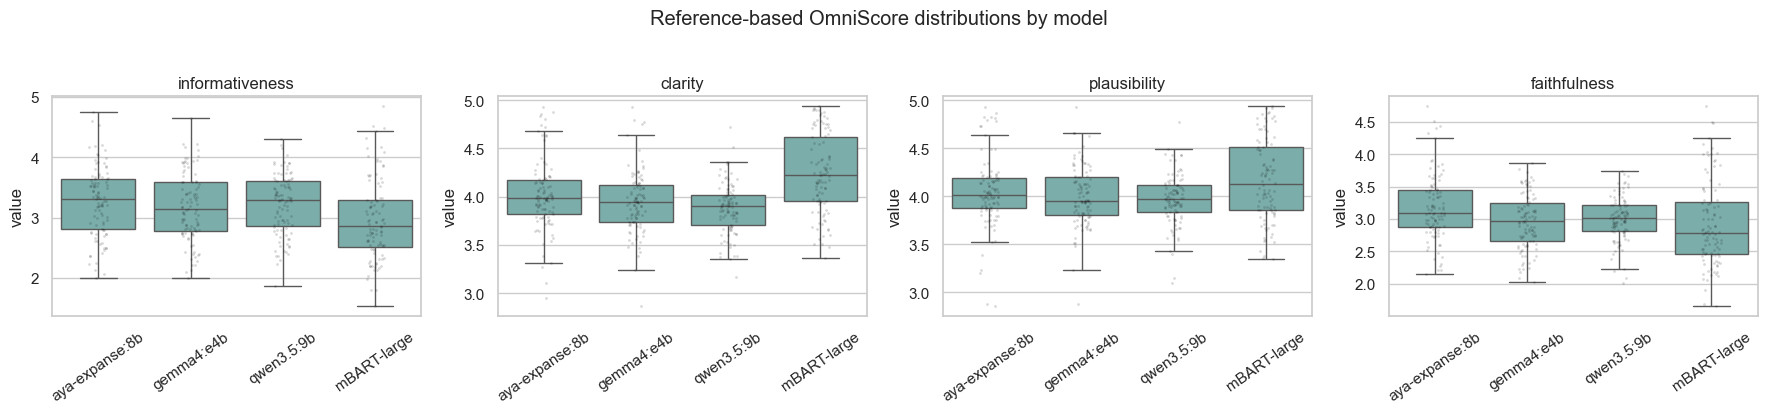

In [8]:
# Cell 7: OmniScore by model
display(Markdown("## Cell 7. Reference-Based OmniScore by Model"))

omniscore_summary = summary_table(df, OMNISCORE_COLS)
omniscore_means = omniscore_summary.pivot(index="metric", columns="model_name", values="mean").reindex(columns=MODEL_ORDER)
display(omniscore_summary.round(4))
display(Markdown("**Mean reference-based OmniScore**"))
display(omniscore_means.round(3))
metric_boxplots(df, OMNISCORE_COLS, "Reference-based OmniScore distributions by model", (18, 4))


## Cell 8. Error-Label Sample Difficulty

**Number of samples by NO-ERROR model count**

,samples
no_error_models,
0,13
1,28
2,30
3,25
4,4


**Hardest samples first**

,no_error_models,error_models,mean_rouge,mean_bertscore,mean_faithfulness,mean_length_ratio,difficulty
sample_index,,,,,,,
30,0,4,25.712,76.648,2.560,1.819,4
93,0,4,26.560,73.298,2.593,1.298,4
55,0,4,15.563,68.275,2.659,1.899,4
38,0,4,20.135,71.688,2.685,2.695,4
39,0,4,21.550,67.862,2.687,1.612,4
57,0,4,23.090,70.078,2.824,2.076,4
47,0,4,26.026,71.442,2.929,1.238,4
6,0,4,22.042,71.960,2.968,1.682,4
81,0,4,17.688,70.892,3.014,2.133,4


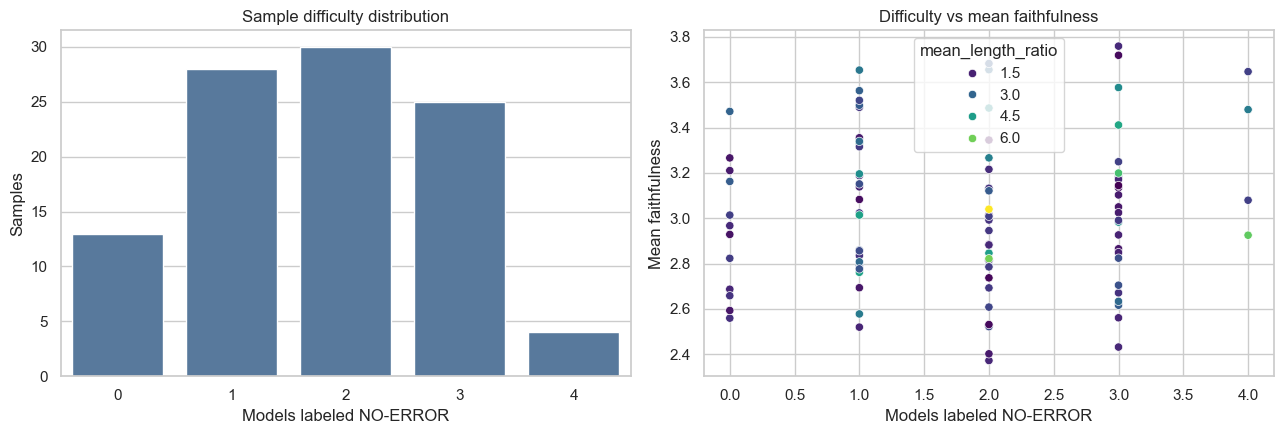

In [9]:
# Cell 8: Sample difficulty based on the number of NO-ERROR models
display(Markdown("## Cell 8. Error-Label Sample Difficulty"))

sample_difficulty = df.groupby("sample_index").agg(
    no_error_models=("is_no_error", "sum"),
    error_models=("has_error", "sum"),
    mean_rouge=("rouge_mean", "mean"),
    mean_bertscore=("bs_f1_raw", "mean"),
    mean_faithfulness=("faithfulness", "mean"),
    mean_length_ratio=("Length Ratio", "mean"),
)
sample_difficulty["difficulty"] = sample_difficulty["error_models"]
difficulty_distribution = sample_difficulty["no_error_models"].value_counts().sort_index().rename("samples").to_frame()
display(Markdown("**Number of samples by NO-ERROR model count**"))
display(difficulty_distribution)
display(Markdown("**Hardest samples first**"))
display(sample_difficulty.sort_values(["difficulty", "mean_faithfulness"], ascending=[False, True]).head(25).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=difficulty_distribution.index, y=difficulty_distribution["samples"], ax=axes[0], color="#4C78A8")
axes[0].set(title="Sample difficulty distribution", xlabel="Models labeled NO-ERROR", ylabel="Samples")
sns.scatterplot(data=sample_difficulty.reset_index(), x="no_error_models", y="mean_faithfulness", hue="mean_length_ratio", palette="viridis", ax=axes[1])
axes[1].set(title="Difficulty vs mean faithfulness", xlabel="Models labeled NO-ERROR", ylabel="Mean faithfulness")
plt.tight_layout()
plt.show()


## Cell 9. Error-Label Pairwise Model Wins

**Row model wins over column model**

,aya-expanse:8b,gemma4:e4b,qwen3.5:9b,mBART-large
aya-expanse:8b,0,15,13,28
gemma4:e4b,40,0,21,50
qwen3.5:9b,33,16,0,42
mBART-large,10,7,4,0


**Pair details**

,model_a,model_b,a_wins,b_wins,net_wins_a_minus_b,both_no_error,both_error
0,aya-expanse:8b,gemma4:e4b,15,40,-25,23,22
1,aya-expanse:8b,qwen3.5:9b,13,33,-20,25,29
2,aya-expanse:8b,mBART-large,28,10,18,10,52
3,gemma4:e4b,qwen3.5:9b,21,16,5,42,21
4,gemma4:e4b,mBART-large,50,7,43,13,30
5,qwen3.5:9b,mBART-large,42,4,38,16,38


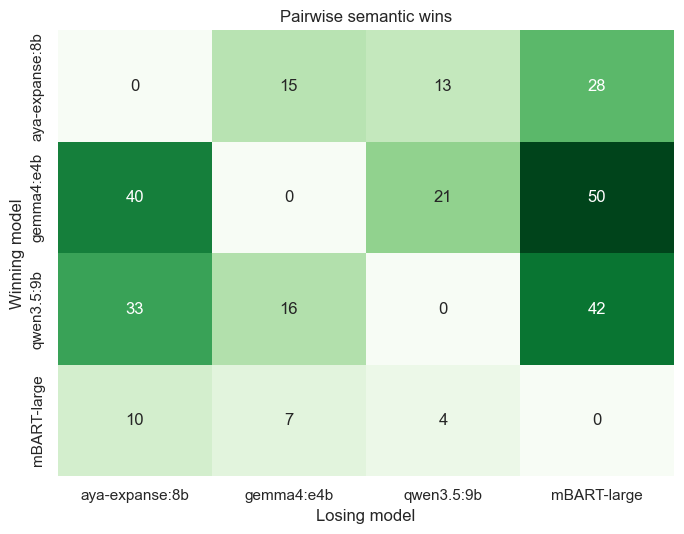

In [10]:
# Cell 9: Pairwise model wins based on semantic labels
display(Markdown("## Cell 9. Error-Label Pairwise Model Wins"))

# A wins over B when A is NO-ERROR and B has at least one error on the same sample.
no_error_wide = df.pivot(index="sample_index", columns="model_name", values="is_no_error").reindex(columns=MODEL_ORDER)
pairwise_wins = pd.DataFrame(0, index=MODEL_ORDER, columns=MODEL_ORDER, dtype=int)
pair_records = []
for model_a, model_b in combinations(MODEL_ORDER, 2):
    a_wins = int((no_error_wide[model_a] & ~no_error_wide[model_b]).sum())
    b_wins = int((no_error_wide[model_b] & ~no_error_wide[model_a]).sum())
    ties_no_error = int((no_error_wide[model_a] & no_error_wide[model_b]).sum())
    ties_error = int((~no_error_wide[model_a] & ~no_error_wide[model_b]).sum())
    pairwise_wins.loc[model_a, model_b] = a_wins
    pairwise_wins.loc[model_b, model_a] = b_wins
    pair_records.append({
        "model_a": model_a, "model_b": model_b,
        "a_wins": a_wins, "b_wins": b_wins,
        "net_wins_a_minus_b": a_wins - b_wins,
        "both_no_error": ties_no_error, "both_error": ties_error,
    })

pairwise_details = pd.DataFrame(pair_records)
display(Markdown("**Row model wins over column model**"))
display(pairwise_wins)
display(Markdown("**Pair details**"))
display(pairwise_details)

plt.figure(figsize=(7, 5.5))
sns.heatmap(pairwise_wins, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Pairwise semantic wins")
plt.xlabel("Losing model")
plt.ylabel("Winning model")
plt.tight_layout()
plt.show()


In [11]:
# Cell 10: Samples where none of the models is NO-ERROR
display(Markdown("## Cell 10. Samples Where No Model Is NO-ERROR"))

no_model_no_error_ids = sample_difficulty.index[sample_difficulty["no_error_models"].eq(0)].tolist()
all_models_no_error_ids = sample_difficulty.index[sample_difficulty["no_error_models"].eq(4)].tolist()
print(f"Samples with zero NO-ERROR models: {len(no_model_no_error_ids)}")
print(f"Samples with four NO-ERROR models: {len(all_models_no_error_ids)}")
display(pd.DataFrame({"sample_index": no_model_no_error_ids}))

hard_sample_rows = (
    df[df["sample_index"].isin(no_model_no_error_ids)]
    [["sample_index", "model_name", "error_label", "Review_Notes", "prediction", "rouge_mean", "bs_f1_raw", "faithfulness", "Length Ratio"]]
    .sort_values(["sample_index", "model_name"])
)
display(hard_sample_rows.head(80).round(3))


## Cell 10. Samples Where No Model Is NO-ERROR

Samples with zero NO-ERROR models: 13
Samples with four NO-ERROR models: 4


,sample_index
0,3
1,6
2,30
3,38
4,39
5,47
6,55
7,57
8,65
9,69


,sample_index,model_name,error_label,Review_Notes,prediction,rouge_mean,bs_f1_raw,faithfulness,Length Ratio
3,3,aya-expanse:8b,H-CIRC|LANG,It invents a specific amount of several hundred yuan and uses dialogue format instead of a summary.,玛丽：嘿，我有点缺钱，能借我几百元吗？\n 卡特：好的，给我一个小时，我在火车站。\n 玛丽：行，谢谢！,13.950,68.02,3.750,2.091
103,3,gemma4:e4b,H-CIRC,It turns Carter's current location at the station into the place where he will give Mary money.,玛丽向卡特借钱，卡特说一小时后在火车站给。,36.267,79.05,2.996,0.955
203,3,qwen3.5:9b,H-CIRC,It turns Carter's current location at the station into the place where he will give Mary money.,玛丽因手头拮据向卡特借钱，卡特表示一小时后在火车站取钱给她。,34.730,77.90,3.494,1.364
303,3,mBART-large,LANG|OMIT,"The phrase about borrowing ""boxes"" is malformed, and the summary omits Carter's promise to lend money in an hour.",玛丽要卡特借几箱钱。卡特在火车站。,24.233,71.71,2.825,0.773
6,6,aya-expanse:8b,H-ROLE,It wrongly attributes the comment about female dogs fighting to Lola.,阿黛尔告诉洛拉她养了一只新的狗，是一只4个月大的小黄狗，名叫骨头（Bones）。其他宠物对新成员反应平静，猫保持距离，而波皮和露露似乎像母亲一样照顾它。斯皮迪想和他一起玩耍。阿黛尔提到幼犬通常比成年狗更容易被其他动物接受。洛拉开玩笑...,27.263,73.42,3.196,2.288
106,6,gemma4:e4b,H-ENT,It misreads a biscuit-colored Labrador as a separate dog breed.,阿黛尔和洛拉聊起阿黛尔新养了一只四个月大的比斯吉犬幼犬，名叫Bones。她们谈到其他宠物对小狗的反应，提到猫咪保持距离，但Poppy和Lulu似乎像母狗一样照顾它，而Speedy则想玩耍。阿黛尔分享了她之前收养的成年狗狗需要断奶，并...,26.397,73.53,3.136,2.068
206,6,qwen3.5:9b,H-CIRC|H-EVT,It reverses age and sex details about the dogs and invents a chewing habit from the puppy's name.,阿黛尔向罗拉介绍她刚领养的四个月大的拉布拉多幼犬“骨头”，性格活泼爱啃咬。家里的猫们保持距离，而两只母狗波皮和露露则像母亲一样照顾它，快嘴也愿意陪它玩，大家相处融洽没有打斗。两人讨论说雌性幼犬更容易被其他动物接纳，不像成年公狗那样需...,20.837,70.33,3.099,2.164
306,6,mBART-large,OMIT,"The puppy named Bones is supported, but the summary omits its age, breed, and the other pets' reactions.","阿黛尔养了一只小狗,名叫骨头。",13.673,70.56,2.439,0.205
30,30,aya-expanse:8b,H-EVT,It changes the request to keep the pasta in the microwave into a request to heat it.,Desiree 问 Lucian 两人是否在家，Lucian 表示刚收到消息，没有特别原因。Desiree 要求将面条放在微波炉里加热。Lucian 回答自己还没做饭。,16.500,70.16,2.268,2.690
130,30,gemma4:e4b,H-EVT,It changes the request to keep the pasta in the microwave into a request to heat it.,迪泽询问卢西安是否在家，并让他把意面放在微波炉里加热。卢西安表示自己什么都没做过饭。,24.047,76.14,2.031,1.448


In [12]:
# Cell 11: Automatic-metric and semantic-label mismatch
display(Markdown("## Cell 11. Automatic Metric vs Semantic Label Mismatch"))

# Global quartiles make the mismatch definition explicit and reproducible.
HIGH_QUANTILE = 0.75
LOW_QUANTILE = 0.25
mismatch_metrics = ["rouge_mean", "bs_f1_raw", "faithfulness"]
thresholds = pd.DataFrame({
    "low_threshold": df[mismatch_metrics].quantile(LOW_QUANTILE),
    "high_threshold": df[mismatch_metrics].quantile(HIGH_QUANTILE),
})
display(Markdown("**Global mismatch thresholds**"))
display(thresholds.round(3))

mismatch_frames = []
for metric in mismatch_metrics:
    high_error = df[df["has_error"] & df[metric].ge(thresholds.loc[metric, "high_threshold"])].copy()
    high_error["mismatch_type"] = f"High {metric} + ERROR"
    high_error["mismatch_metric"] = metric
    mismatch_frames.append(high_error)

for metric in ["rouge_mean", "bs_f1_raw"]:
    low_no_error = df[df["is_no_error"] & df[metric].le(thresholds.loc[metric, "low_threshold"])].copy()
    low_no_error["mismatch_type"] = f"Low {metric} + NO-ERROR"
    low_no_error["mismatch_metric"] = metric
    mismatch_frames.append(low_no_error)

mismatches = pd.concat(mismatch_frames, ignore_index=True)
mismatch_counts = pd.crosstab(mismatches["model_name"], mismatches["mismatch_type"]).reindex(MODEL_ORDER, fill_value=0)
display(Markdown("**Mismatch counts by model**"))
display(mismatch_counts)

mismatch_examples = mismatches[[
    "mismatch_type", "sample_index", "model_name", "error_label", "Review_Notes",
    "rouge_mean", "bs_f1_raw", "faithfulness", "Length Ratio", "prediction"
]].sort_values(["mismatch_type", "model_name", "sample_index"])
display(Markdown("**Mismatch examples**"))
display(mismatch_examples.head(100).round(3))


## Cell 11. Automatic Metric vs Semantic Label Mismatch

**Global mismatch thresholds**

,low_threshold,high_threshold
rouge_mean,14.172,26.998
bs_f1_raw,68.088,75.248
faithfulness,2.692,3.296


**Mismatch counts by model**

mismatch_type,High bs_f1_raw + ERROR,High faithfulness + ERROR,High rouge_mean + ERROR,Low bs_f1_raw + NO-ERROR,Low rouge_mean + NO-ERROR
model_name,,,,,
aya-expanse:8b,6,25,10,8,12
gemma4:e4b,6,6,8,15,18
qwen3.5:9b,4,9,5,16,16
mBART-large,34,13,29,0,0


**Mismatch examples**

,mismatch_type,sample_index,model_name,error_label,Review_Notes,rouge_mean,bs_f1_raw,faithfulness,Length Ratio,prediction
52,High bs_f1_raw + ERROR,12,aya-expanse:8b,H-ROLE,It partly assigns the planned 8 p.m. call to Jordan instead of Elliot.,37.663,78.89,3.068,1.925,埃利奥特现在很忙，无法接听电话，提议两小时后再打电话。乔丹正在去参加同事布拉德的葬礼，晚上八点会打电话给埃利奥特。埃利奥特表示了慰问，并承诺在晚上八点打电话。布拉德因肝癌去世，乔丹之前已经提到过这个情况。
53,High bs_f1_raw + ERROR,29,aya-expanse:8b,H-ROLE,It attributes the compliment about the black dress to Raphael instead of Frank.,35.167,75.91,3.164,2.778,杰西卡去城里二手店买了很多东西，包括一张橡木桌、六把椅子、一个花瓶和一堆衣服。她发了照片给拉斐尔和弗兰克，他们都非常喜欢那张桌子，尤其是拉斐尔对黑色的连衣裙赞不绝口。杰西卡对自己的购买感到非常满意，更令人高兴的是，她只花了70欧元就...
54,High bs_f1_raw + ERROR,40,aya-expanse:8b,OMIT,It omits the key cause of the laptop failure: the cat spilled coffee on it.,32.527,76.77,3.008,1.618,迪玛的笔记本电脑坏了，明天需要交翻译，但 Nada 的旧笔记本电脑已经借给了她哥哥。 尽管如此，Nada 还是同意让迪玛使用她的笔记本电脑，因为她这两天都请假了。 迪玛表示非常感激，并承认他们应该为翻译工作准备备用笔记本电脑。 她想...
55,High bs_f1_raw + ERROR,53,aya-expanse:8b,H-ROLE,It unsupportedly makes the police the publisher of both the official statement and newspaper article.,27.457,75.76,3.130,1.370,有个人在校园被打和抢，正在医院恢复。攻击者戴着面具，警方将发布官方声明并发表报纸文章。大家猜测攻击者可能是学生，甚至可能只是为了好玩。尽管校园有监控摄像头，但安全卫士效率不高。希望犯罪分子能尽快被捕。
56,High bs_f1_raw + ERROR,56,aya-expanse:8b,H-ENT,It incorrectly changes Chloe's name to Joey.,31.383,78.47,3.098,1.919,艾米丽问下一次ASEEES会议将在哪里举行。乔伊表示不知道，但这是一个好问题。詹姆斯听说过在加利福尼亚，具体是旧金山。乔伊希望会议能去夏威夷，但詹姆斯认为由于1993年最后一次在那里举行的会议因交通费用高而受到批评，未来可能不会太快实现。
...,...,...,...,...,...,...,...,...,...,...
147,High faithfulness + ERROR,43,mBART-large,H-ROLE,It assigns the 11 p.m. return requirement to Daisy instead of Lisa.,53.830,88.73,3.992,0.952,黛西想在晚上11点前回家。丽莎还没回家。
148,High faithfulness + ERROR,44,mBART-large,OMIT,It accurately describes Cindy's refusal to explain her sadness but omits Ellie's unseen viral video.,25.857,68.75,3.820,0.800,"辛迪很伤心,因为发生了一些事,她不想谈论这件事。"
149,High faithfulness + ERROR,46,mBART-large,H-ROLE,"It says Mum installed the dishwasher, while outside installers installed it for Steve.",38.097,82.15,4.027,0.882,妈妈给史蒂夫安装了一台洗碗机。
150,High faithfulness + ERROR,61,mBART-large,OMIT,"The milk purchase is correct, but the condition that Martin will do it after completing the plan is omitted.",64.837,90.57,3.894,0.737,马丁会给亚历克斯买两瓶牛奶。


## Cell 12. Length Ratio vs Error Type

`OVER-SUP` is not present in the current taxonomy and is therefore not included in this analysis.

**Label occurrence rate within each Length Ratio bin**

label,H-ENT,H-EVT,H-ROLE,H-CIRC,H-MOD,H-DISC,OMIT,LANG,NO-ERROR
length_ratio_bin,,,,,,,,,
<0.75,0.100,0.200,0.100,0.250,0.125,0.050,0.650,0.075,0.175
0.75-1.25,0.100,0.267,0.100,0.067,0.167,0.117,0.300,0.050,0.400
1.25-2.0,0.122,0.144,0.189,0.089,0.044,0.011,0.133,0.078,0.456
2.0-4.0,0.083,0.083,0.160,0.104,0.021,0.049,0.062,0.062,0.500
>4.0,0.091,0.076,0.167,0.030,0.061,0.076,0.015,0.091,0.530


**Length Ratio correlation with each label indicator**

,label,spearman_rho_ratio,p_value_ratio,spearman_rho_log_ratio,p_value_log_ratio,label_rows
8,NO-ERROR,0.1699,0.0006,0.1699,0.0006,179
2,H-ROLE,0.0401,0.4234,0.0401,0.4234,61
7,LANG,0.0270,0.5899,0.0270,0.5899,28
5,H-DISC,-0.0081,0.8714,-0.0081,0.8714,22
0,H-ENT,-0.0376,0.4530,-0.0376,0.4530,39
3,H-CIRC,-0.1155,0.0209,-0.1155,0.0209,39
4,H-MOD,-0.1266,0.0113,-0.1266,0.0113,26
1,H-EVT,-0.1915,0.0001,-0.1915,0.0001,54
6,OMIT,-0.4233,0.0000,-0.4233,0.0000,66


**Model-level length and semantic-error profile**

,mean_length_ratio,median_length_ratio,no_error_rate,hallucination_rate,omit_rate,lang_rate
model_name,,,,,,
aya-expanse:8b,3.518,2.826,0.38,0.43,0.07,0.17
gemma4:e4b,2.398,2.067,0.63,0.29,0.08,0.00
qwen3.5:9b,2.894,2.300,0.58,0.39,0.03,0.00
mBART-large,1.026,0.842,0.20,0.61,0.48,0.11


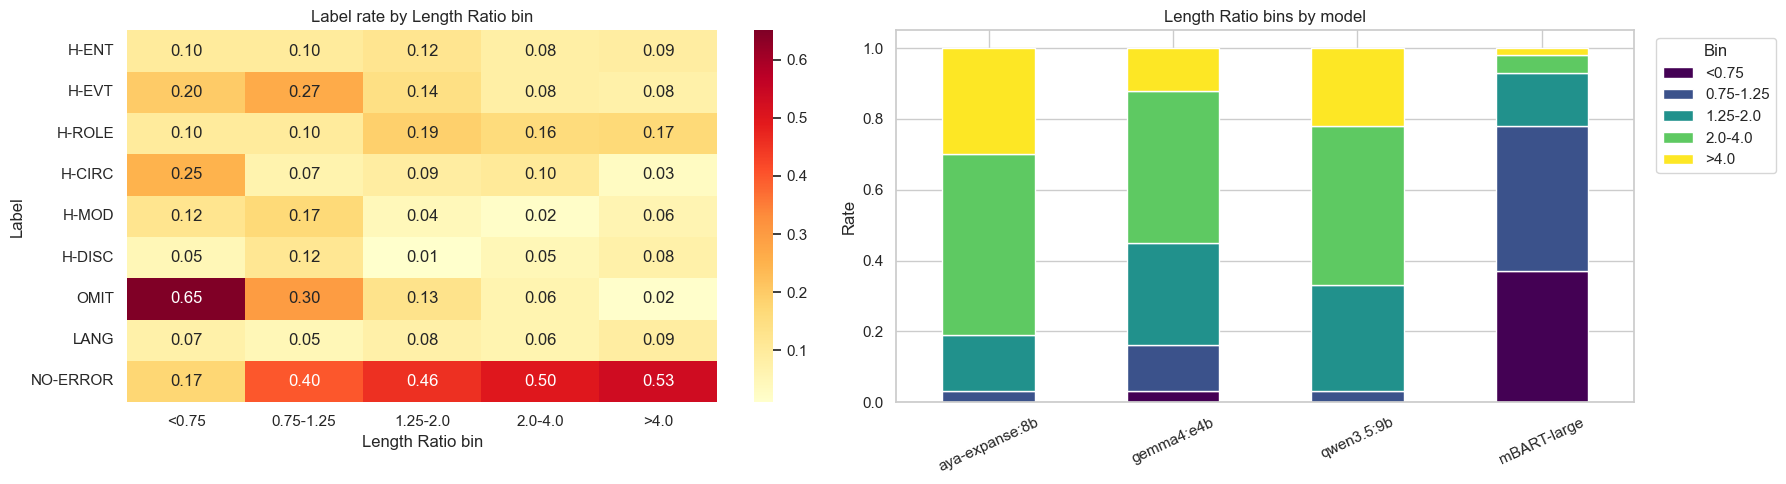

In [13]:
# Cell 12: Length Ratio and error-type relationships
display(Markdown("## Cell 12. Length Ratio vs Error Type"))
display(Markdown("`OVER-SUP` is not present in the current taxonomy and is therefore not included in this analysis."))

bin_sizes = df["length_ratio_bin"].value_counts().reindex(LENGTH_BIN_ORDER, fill_value=0)
bin_label_counts = pd.crosstab(label_long["length_ratio_bin"], label_long["label"]).reindex(index=LENGTH_BIN_ORDER, columns=TAXONOMY_LABELS, fill_value=0)
bin_label_rates = bin_label_counts.div(bin_sizes, axis=0)
display(Markdown("**Label occurrence rate within each Length Ratio bin**"))
display(bin_label_rates.round(3))

# Spearman correlation is calculated against one binary indicator per label.
correlation_records = []
for label in TAXONOMY_LABELS:
    indicator = df["label_list"].apply(lambda labels: int(label in labels))
    rho_raw, p_raw = spearmanr(df["Length Ratio"], indicator)
    rho_log, p_log = spearmanr(np.log(df["Length Ratio"].clip(lower=1e-12)), indicator)
    correlation_records.append({
        "label": label,
        "spearman_rho_ratio": rho_raw,
        "p_value_ratio": p_raw,
        "spearman_rho_log_ratio": rho_log,
        "p_value_log_ratio": p_log,
        "label_rows": int(indicator.sum()),
    })
length_label_correlations = pd.DataFrame(correlation_records).sort_values("spearman_rho_log_ratio", ascending=False)
display(Markdown("**Length Ratio correlation with each label indicator**"))
display(length_label_correlations.round(4))

model_length_error_profile = df.groupby("model_name", observed=True).agg(
    mean_length_ratio=("Length Ratio", "mean"),
    median_length_ratio=("Length Ratio", "median"),
    no_error_rate=("is_no_error", "mean"),
    hallucination_rate=("is_hallucination", "mean"),
    omit_rate=("is_omit", "mean"),
    lang_rate=("is_lang", "mean"),
).reindex(MODEL_ORDER)
display(Markdown("**Model-level length and semantic-error profile**"))
display(model_length_error_profile.round(3))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.heatmap(bin_label_rates.T, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[0])
axes[0].set(title="Label rate by Length Ratio bin", xlabel="Length Ratio bin", ylabel="Label")
model_bin_rates = pd.crosstab(df["model_name"], df["length_ratio_bin"], normalize="index").reindex(index=MODEL_ORDER, columns=LENGTH_BIN_ORDER, fill_value=0)
model_bin_rates.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set(title="Length Ratio bins by model", xlabel="", ylabel="Rate")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="Bin", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Cell 13. Multi-Label Co-Occurrence

Multi-label rows: 76 / 400 (19.0%)


,label_a,label_b,count
0,H-EVT,OMIT,19
1,H-EVT,H-ROLE,11
2,H-CIRC,H-EVT,10
3,H-CIRC,OMIT,9
4,H-ENT,H-ROLE,8
5,H-ROLE,OMIT,8
6,H-EVT,H-MOD,8
7,H-ENT,H-EVT,8
8,H-ENT,OMIT,8
9,H-CIRC,H-MOD,7


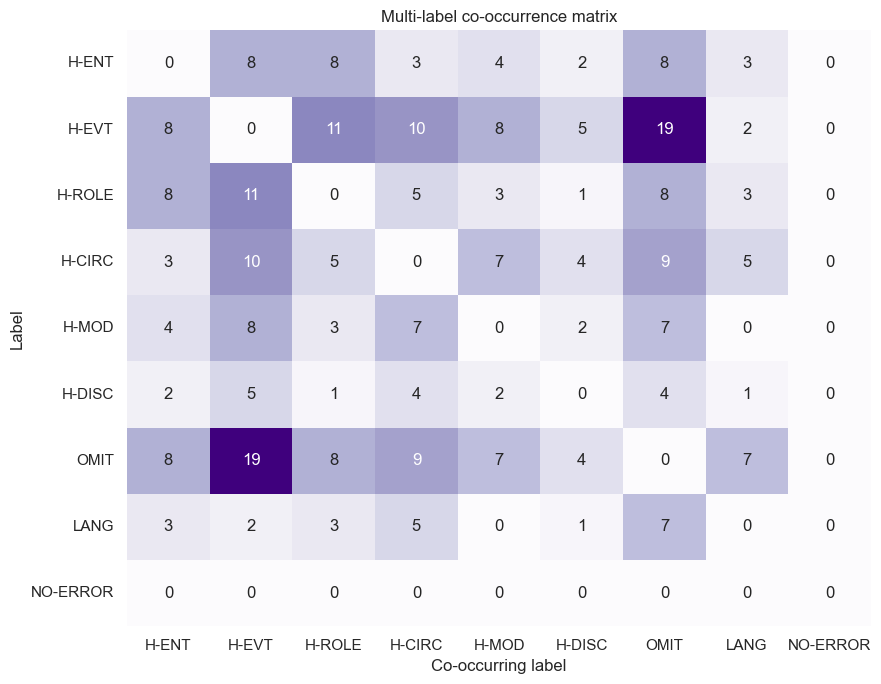

In [14]:
# Cell 13: Multi-label co-occurrence
display(Markdown("## Cell 13. Multi-Label Co-Occurrence"))

multi_rows = df[df["is_multi_label"]].copy()
pair_counter = Counter()
for labels in multi_rows["label_list"]:
    for label_a, label_b in combinations(sorted(labels), 2):
        pair_counter[(label_a, label_b)] += 1

pair_counts = pd.DataFrame([
    {"label_a": pair[0], "label_b": pair[1], "count": count}
    for pair, count in pair_counter.most_common()
])
print(f"Multi-label rows: {len(multi_rows)} / {len(df)} ({len(multi_rows) / len(df):.1%})")
display(pair_counts)

cooccurrence = pd.DataFrame(0, index=TAXONOMY_LABELS, columns=TAXONOMY_LABELS, dtype=int)
for labels in multi_rows["label_list"]:
    for label_a in labels:
        for label_b in labels:
            if label_a != label_b:
                cooccurrence.loc[label_a, label_b] += 1

plt.figure(figsize=(9, 7))
sns.heatmap(cooccurrence, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title("Multi-label co-occurrence matrix")
plt.xlabel("Co-occurring label")
plt.ylabel("Label")
plt.tight_layout()
plt.show()


## Cell 14. mBART vs SLMs: Integrated Comparison

**Integrated family summary**

,rows,no_error_rate,hallucination_rate,omit_rate,lang_rate,multi_label_rate,mean_length_ratio,median_length_ratio,mean_rouge,mean_bertscore,mean_informativeness,mean_clarity,mean_plausibility,mean_faithfulness
system_family,,,,,,,,,,,,,,
SLMs,300,0.53,0.37,0.06,0.057,0.077,2.937,2.474,19.546,70.479,3.217,3.948,4.003,3.043
mBART,100,0.20,0.61,0.48,0.110,0.530,1.026,0.842,31.633,77.644,2.968,4.242,4.166,2.922


**Taxonomy label rates by family**

label,H-ENT,H-EVT,H-ROLE,H-CIRC,H-MOD,H-DISC,OMIT,LANG,NO-ERROR
system_family,,,,,,,,,
SLMs,0.077,0.073,0.133,0.077,0.037,0.04,0.06,0.057,0.53
mBART,0.160,0.320,0.210,0.160,0.150,0.10,0.48,0.110,0.20


**Length Ratio bin rates by family**

length_ratio_bin,<0.75,0.75-1.25,1.25-2.0,2.0-4.0,>4.0
system_family,,,,,
SLMs,0.01,0.063,0.25,0.463,0.213
mBART,0.37,0.410,0.15,0.050,0.020


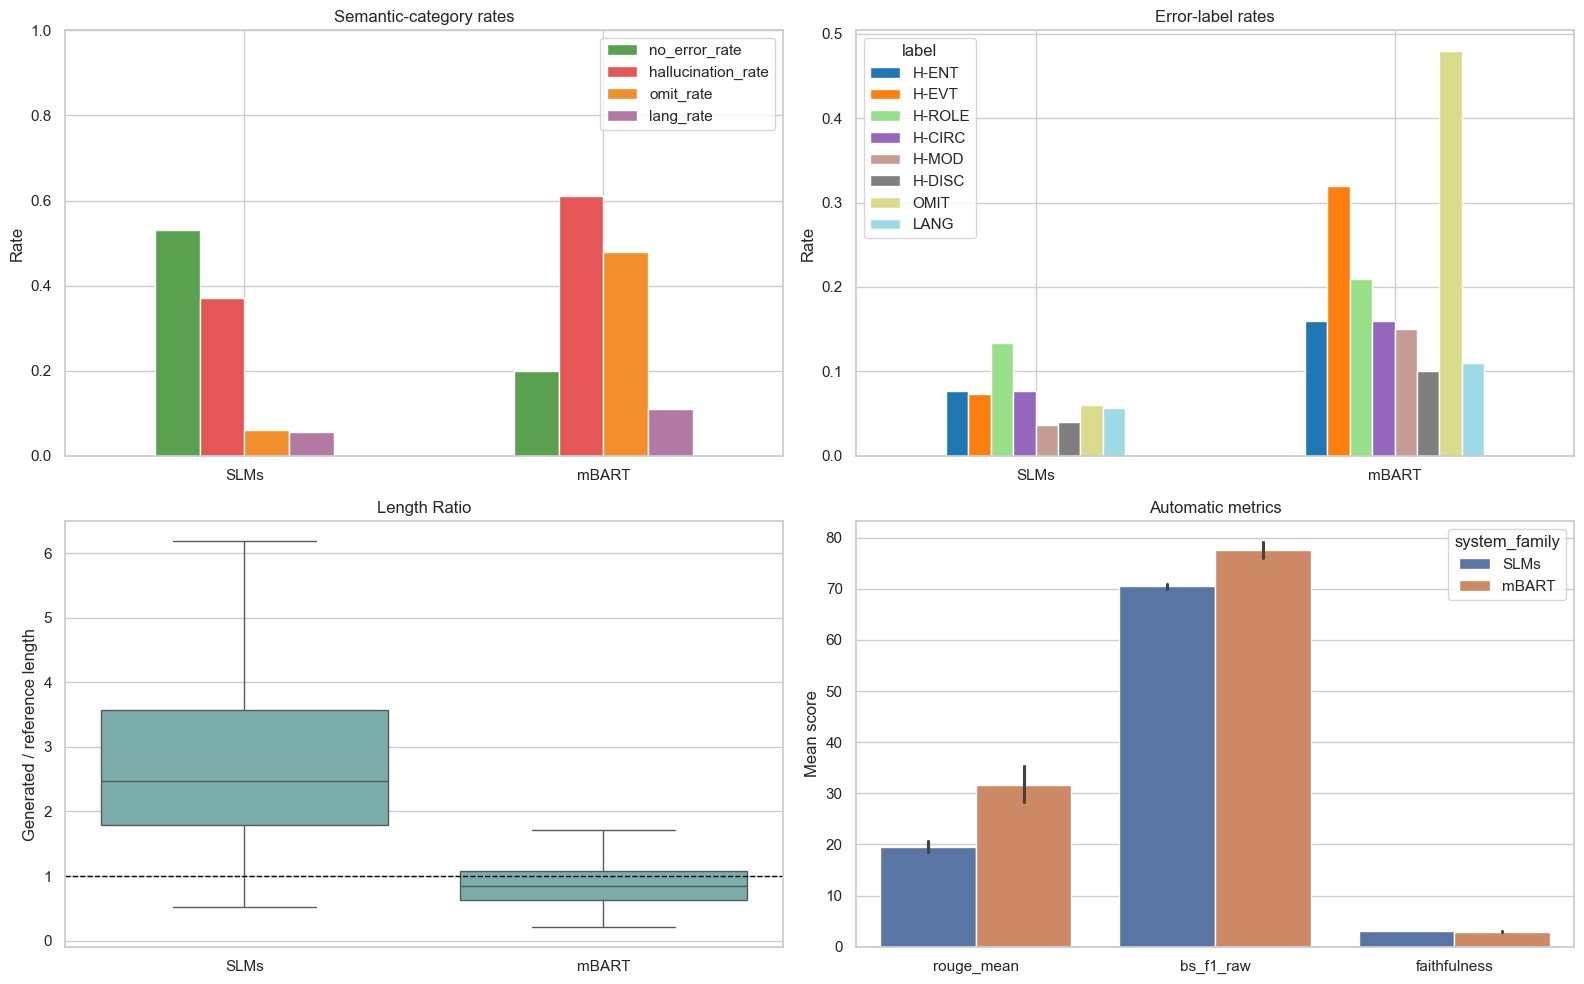

In [15]:
# Cell 14: Integrated comparison of mBART and SLMs
display(Markdown("## Cell 14. mBART vs SLMs: Integrated Comparison"))

family_summary = df.groupby("system_family").agg(
    rows=("sample_index", "size"),
    no_error_rate=("is_no_error", "mean"),
    hallucination_rate=("is_hallucination", "mean"),
    omit_rate=("is_omit", "mean"),
    lang_rate=("is_lang", "mean"),
    multi_label_rate=("is_multi_label", "mean"),
    mean_length_ratio=("Length Ratio", "mean"),
    median_length_ratio=("Length Ratio", "median"),
    mean_rouge=("rouge_mean", "mean"),
    mean_bertscore=("bs_f1_raw", "mean"),
    mean_informativeness=("informativeness", "mean"),
    mean_clarity=("clarity", "mean"),
    mean_plausibility=("plausibility", "mean"),
    mean_faithfulness=("faithfulness", "mean"),
)
display(Markdown("**Integrated family summary**"))
display(family_summary.round(3))

family_label_counts = pd.crosstab(label_long["system_family"], label_long["label"]).reindex(columns=TAXONOMY_LABELS, fill_value=0)
family_sizes = df.groupby("system_family").size()
family_label_rates = family_label_counts.div(family_sizes, axis=0)
display(Markdown("**Taxonomy label rates by family**"))
display(family_label_rates.round(3))

# Compare mBART with the average SLM outcome on each identical sample.
sample_family = df.groupby(["sample_index", "system_family"]).agg(
    no_error_rate=("is_no_error", "mean"),
    hallucination_rate=("is_hallucination", "mean"),
    omit_rate=("is_omit", "mean"),
    lang_rate=("is_lang", "mean"),
    rouge_mean=("rouge_mean", "mean"),
    bertscore_mean=("bs_f1_raw", "mean"),
    faithfulness_mean=("faithfulness", "mean"),
    length_ratio_mean=("Length Ratio", "mean"),
).reset_index()

family_length_bins = pd.crosstab(df["system_family"], df["length_ratio_bin"], normalize="index").reindex(columns=LENGTH_BIN_ORDER, fill_value=0)
display(Markdown("**Length Ratio bin rates by family**"))
display(family_length_bins.round(3))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
family_summary[["no_error_rate", "hallucination_rate", "omit_rate", "lang_rate"]].plot(kind="bar", ax=axes[0, 0], color=["#59A14F", "#E45756", "#F28E2B", "#B279A2"])
axes[0, 0].set(title="Semantic-category rates", xlabel="", ylabel="Rate", ylim=(0, 1))
axes[0, 0].tick_params(axis="x", rotation=0)
family_label_rates.drop(columns="NO-ERROR", errors="ignore").plot(kind="bar", ax=axes[0, 1], colormap="tab20")
axes[0, 1].set(title="Error-label rates", xlabel="", ylabel="Rate")
axes[0, 1].tick_params(axis="x", rotation=0)
sns.boxplot(data=df, x="system_family", y="Length Ratio", ax=axes[1, 0], color="#72B7B2", showfliers=False)
axes[1, 0].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[1, 0].set(title="Length Ratio", xlabel="", ylabel="Generated / reference length")
metric_family_long = df.melt(id_vars=["system_family"], value_vars=["rouge_mean", "bs_f1_raw", "faithfulness"], var_name="metric", value_name="value")
sns.barplot(data=metric_family_long, x="metric", y="value", hue="system_family", ax=axes[1, 1], errorbar="ci")
axes[1, 1].set(title="Automatic metrics", xlabel="", ylabel="Mean score")
plt.tight_layout()
plt.show()
